# Proyecto Deep Learning Spotify: Tarea 3 - Modelo 1: Más Neuronas

## Configuración del entorno

In [ ]:
%pip install -r ../requirements.txt

In [11]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras.callbacks import EarlyStopping

sys.path.append(os.path.abspath('..'))
from models.T3_M1_mas_neuronas import crear_modelo

In [5]:
df = pd.read_csv(r'..\data\data.csv')

df_limpio = df[
    (df['duration_ms'] > 40000) & 
    (df['speechiness'] < 0.90) & 
    (df['tempo'] > 0)
].copy()

cols_to_drop = ['popularity', 'id', 'name', 'artists', 'id_artists', 'release_date', 'mode']
X = df_limpio.drop(columns=cols_to_drop, errors='ignore')
y = df_limpio['popularity']

In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [ ]:
modelo_nn = crear_modelo(X_train_scaled.shape[1])

print("RESUMEN DE LA ARQUITECTURA (NÚMERO DE PARÁMETROS)")
modelo_nn.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=30,
    restore_best_weights=True
)

historia = modelo_nn.fit(
    X_train_scaled, y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=500,
    batch_size=64,
    verbose=1
)

RESUMEN DE LA ARQUITECTURA (NÚMERO DE PARÁMETROS)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 16)             │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 241 (964.00 B)

 Trainable params: 241 (964.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/500
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 502.3009 - mae: 16.4348 - val_loss: 153.5117 - val_mae: 9.3185
Epoch 2/500
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 132.5617 - mae: 8.5141 - val_loss: 122.3439 - val_mae: 8.1268
Epoch 3/500
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - loss: 120.7014 - mae: 8.1309 - val_loss: 117.9027 - val_mae: 8.0341
Epoch 4/500
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 117.4067 - mae: 8.0498 - val_loss: 116.0825 - val_mae: 7.9684
Epoch 5/500
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 115.9901 - mae: 8.0124 - val_loss: 115.1278 - val_mae: 7.9264
Epoch 6/500
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 115.0803 - mae: 7.9784 - val_loss: 114.5018 - val_mae: 7.9521
Epoch 7/500
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 114.4053 - mae: 7.9498 - val_loss: 113.8457 - val_mae: 7.9072
Epoch 8/500
1816/1816 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 113.7278 - mae: 7.9126 - val_loss: 113.0422 - val_mae: 7.8520

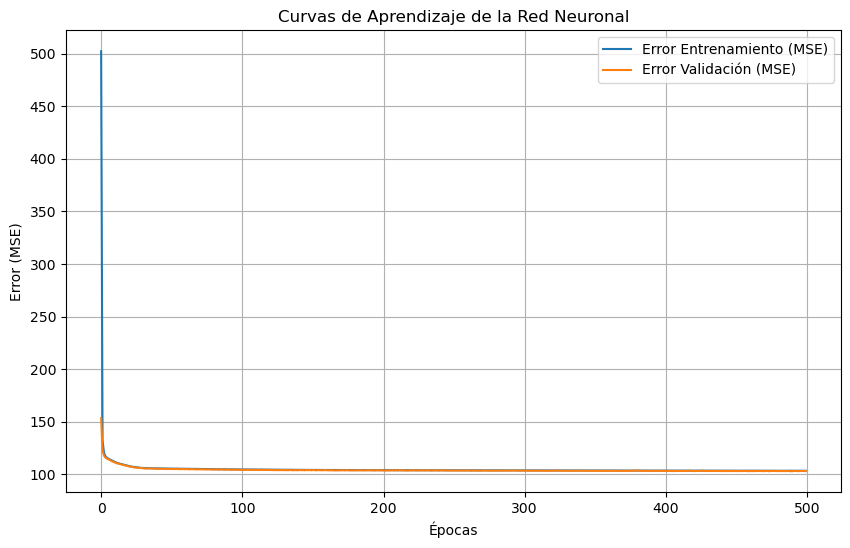

In [17]:
plt.figure(figsize=(10, 6))
plt.plot(historia.history['loss'], label='Error Entrenamiento (MSE)')
plt.plot(historia.history['val_loss'], label='Error Validación (MSE)')
plt.title('Curvas de Aprendizaje de la Red Neuronal')
plt.xlabel('Épocas')
plt.ylabel('Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

In [18]:
def evaluar_red(modelo, X_data, y_true, nombre_conjunto):
    y_pred = modelo.predict(X_data, verbose=0).flatten()
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"--- Resultados en {nombre_conjunto} ---")
    print(f"MSE:  {mse:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²:   {r2:.4f}\n")

print("EVALUACIÓN RED NEURONAL\n")

evaluar_red(modelo_nn, X_train_scaled, y_train, "ENTRENAMIENTO")
evaluar_red(modelo_nn, X_val_scaled, y_val, "VALIDACIÓN")
evaluar_red(modelo_nn, X_test_scaled, y_test, "TEST")

EVALUACIÓN RED NEURONAL

--- Resultados en ENTRENAMIENTO ---
MSE:  103.53
RMSE: 10.17
R²:   0.7775

--- Resultados en VALIDACIÓN ---
MSE:  103.23
RMSE: 10.16
R²:   0.7790

--- Resultados en TEST ---
MSE:  99.27
RMSE: 9.96
R²:   0.7845

